
# ResiliSeed Bio proof of concept

This notebook is a **benchmark-informed synthetic proof of concept** for the ResiliSeed Bio platform.

It does **not** use real experimental observations. Instead, it simulates seed-lot level and treatment-level data using effect sizes and directional patterns informed by plant stress and seed-priming literature indexed in **PubMed** and visible records from **AGRIS**.

## Scientific question

Can a seed-stage discovery, intervention, and prediction engine identify:
1. biomarker signatures associated with stronger performance under **compound heat + drought stress**,
2. candidate priming or resilience-primer interventions that improve establishment and recovery,
3. a practical ML model that predicts which seed lots are most likely to benefit?

## Literature-informed benchmark assumptions used to simulate the data

| Evidence source | Benchmark signal used in simulation |
|---|---|
| Guo et al., 2022, *Seed Priming With Melatonin Promotes Seed Germination and Seedling Growth of Triticale hexaploide L. Under PEG-6000 Induced Drought Stress*, PMC / PubMed | Melatonin priming increased drought-stressed germination rate by **57.67%** relative to unprimed seeds and reduced oxidative damage. |
| Wang et al., 2022, *Seed priming with protein hydrolysate promotes seed germination via reserve mobilization, osmolyte accumulation and antioxidant systems under PEG-induced drought stress*, PubMed | Protein hydrolysate priming improved tomato germination and seedling growth under drought, increased osmolytes and antioxidant activity, and reduced MDA / membrane damage. |
| Wang et al., 2016, *Effects of pre-sowing seed treatments on establishment of dry direct-seeded early rice under chilling stress*, PMC / PubMed | Seed priming increased rice germination by **20.96–26.31%** under chilling stress. This range is used as a conservative generic priming uplift baseline. |
| Habibi et al., 2023, *Potential Benefits of Seed Priming under Salt Stress Conditions on Physiological and Biochemical Attributes of Micro-Tom Tomato Plants*, PMC | Under severe salt stress, leaf electrolyte leakage reached about **50.36%** in non-primed plants; primed treatments lowered leakage into the **~32–38%** range. MDA rose from **4.45** in control to **22.29** at severe stress in non-primed plants, while priming reduced it to **~17.75–19.40**. These ranges anchor synthetic oxidative-stress variables. |
| Catiempo et al., 2021, AGRIS record, *Impact of hydropriming on germination and seedling establishment of sunflower seeds at elevated temperature* | Hydropriming for **12–18 h** increased germination percentage, germination index, vigour index, seedling dry weight, and shoot length under elevated temperature. Used as directional support for hydropriming and thermopriming-like effects. |
| Hassan et al., 2022, AGRIS record, *Effect of foliar application of Cycocyl, Salicylic Acid and Humic acid on physiological and productivity parameters of potato under water stress conditions* | Water stress increased **electrolyte leakage**, **electrical conductivity**, and **proline**. Salicylic acid treatment improved yield and water-use efficiency, while CCC increased catalase activity. Used to shape stress-biomarker directions and stress-relief treatment logic. |
| Dhanya et al., 2024, AGRIS record, *Induction of heat stress tolerance in barley* | Seeds primed at **30°C for 12 h** improved germination potential and vigour under heat stress, supporting heat-focused conditioning effects. |

## Caveat

The values below are **synthetic**, but constrained so that:
- untreated stress depresses germination, vigour, and recovery,
- stress elevates electrolyte leakage, MDA, and proline,
- better interventions improve germination, seedling growth, and recovery while reducing oxidative damage,
- advanced interventions outperform basic hydropriming on average but not in every seed lot.

## Source links
- Guo et al. 2022 https://doi.org/10.3389/fpls.2022.932912
- Wang et al. 2022 https://doi.org/10.1007/s00299-022-02914-6
- Wang et al. 2016 https://doi.org/10.1093/aobpla/plw074
- Habibi et al. 2023 PMC: https://doi.org/10.3390/plants12112187
- AGRIS hydropriming sunflower: https://agris.fao.org/search/en/providers/122644/records/6565ee84c5a6e8c12480d37f
- AGRIS potato water stress: https://agris.fao.org/search/en/providers/122526/records/65e9b7661b4be2d52a177558
- AGRIS barley heat priming: https://agris.fao.org/search/en/providers/122436/records/67599536c7a957febdfd3327


In [4]:

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_recall_fscore_support,
    confusion_matrix, RocCurveDisplay, mean_squared_error, r2_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

np.random.seed(42)

BASE_DIR = Path('resiliseed_poc')
FIG_DIR = BASE_DIR / 'figures'
TAB_DIR = BASE_DIR / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)


In [6]:

benchmark_effects = {
    "generic_priming_germination_uplift_pct": (20.96, 26.31),
    "melatonin_relative_germination_gain_pct": 57.67,
    "tomato_severe_stress_el_nonprimed_pct": 50.36,
    "tomato_severe_stress_el_primed_pct_range": (32.22, 38.53),
    "tomato_control_mda_range": (3.54, 4.45),
    "tomato_severe_stress_mda_nonprimed": 22.29,
    "tomato_severe_stress_mda_primed_range": (17.75, 19.40),
    "agris_potato_catalase_umol_g_reference": 0.05,
    "agris_potato_proline_ppm_reference": 64.83,
}
pd.DataFrame([{"parameter": k, "benchmark": v} for k, v in benchmark_effects.items()])


,parameter,benchmark
0,generic_priming_germination_uplift_pct,"(20.96, 26.31)"
1,melatonin_relative_germination_gain_pct,57.67
2,tomato_severe_stress_el_nonprimed_pct,50.36
3,tomato_severe_stress_el_primed_pct_range,"(32.22, 38.53)"
4,tomato_control_mda_range,"(3.54, 4.45)"
5,tomato_severe_stress_mda_nonprimed,22.29
6,tomato_severe_stress_mda_primed_range,"(17.75, 19.4)"
7,agris_potato_catalase_umol_g_reference,0.05
8,agris_potato_proline_ppm_reference,64.83


In [8]:

crops = ["Tomato", "Pepper"]
genotype_classes = ["Sensitive", "Intermediate", "Tolerant"]
seed_age_classes = ["Fresh", "Mid-storage", "Aged"]
stress_levels = ["Control", "Heat", "Drought", "Heat+Drought"]
interventions = ["None", "Hydropriming", "Melatonin", "ProteinHydrolysate", "ResiliencePrimer"]

n_seed_lots_per_crop = 36
replicates = 5

rows = []
lot_counter = 0

for crop in crops:
    for i in range(n_seed_lots_per_crop):
        lot_counter += 1

        genotype = np.random.choice(genotype_classes, p=[0.33, 0.34, 0.33])
        age = np.random.choice(seed_age_classes, p=[0.40, 0.35, 0.25])

        genotype_score = {"Sensitive": -1.0, "Intermediate": 0.0, "Tolerant": 1.0}[genotype]
        age_score = {"Fresh": 0.8, "Mid-storage": 0.0, "Aged": -0.9}[age]
        crop_score = {"Tomato": 0.1, "Pepper": -0.1}[crop]

        latent_vigor = np.random.normal(0, 1) + 0.8 * genotype_score + 0.7 * age_score + crop_score
        latent_tolerance = np.random.normal(0, 1) + 1.0 * genotype_score + 0.2 * age_score

        baseline_germ = np.clip(84 + 5.5*genotype_score + 3.5*age_score + np.random.normal(0, 3), 55, 99)
        baseline_root = np.clip(4.8 + 1.2*genotype_score + 0.7*age_score + np.random.normal(0, 0.6), 1.8, 8.5)
        baseline_shoot = np.clip(4.2 + 0.8*genotype_score + 0.6*age_score + np.random.normal(0, 0.5), 1.5, 7.5)
        baseline_el = np.clip(24 - 3.5*genotype_score - 2.0*age_score + np.random.normal(0, 2), 10, 38)
        baseline_mda = np.clip(4.0 - 0.3*genotype_score - 0.2*age_score + np.random.normal(0, 0.3), 2.8, 5.4)
        baseline_proline = np.clip(20 + 4*genotype_score + 2*age_score + np.random.normal(0, 3), 10, 35)
        baseline_catalase = np.clip(0.020 + 0.003*genotype_score + 0.002*age_score + np.random.normal(0, 0.002), 0.010, 0.035)

        for stress in stress_levels:
            stress_penalty = {"Control": 0.0, "Heat": 0.17, "Drought": 0.24, "Heat+Drought": 0.36}[stress]
            vigour_penalty = {"Control": 0.0, "Heat": 0.20, "Drought": 0.28, "Heat+Drought": 0.42}[stress]
            oxidative_push = {"Control": 0.0, "Heat": 7.0, "Drought": 10.0, "Heat+Drought": 15.0}[stress]
            mda_push = {"Control": 0.0, "Heat": 2.5, "Drought": 4.5, "Heat+Drought": 8.5}[stress]
            proline_push = {"Control": 0.0, "Heat": 8.0, "Drought": 18.0, "Heat+Drought": 26.0}[stress]

            tolerance_modifier = 1 - np.clip(0.10*latent_tolerance, -0.15, 0.18)

            for intervention in interventions:
                if intervention == "None":
                    germ_relief, vigour_relief, el_reduction, mda_reduction, proline_reduction, catalase_boost = 0,0,0,0,0,0
                elif intervention == "Hydropriming":
                    germ_relief = np.random.uniform(0.10, 0.18)
                    vigour_relief = np.random.uniform(0.10, 0.20)
                    el_reduction = np.random.uniform(0.08, 0.14)
                    mda_reduction = np.random.uniform(0.08, 0.14)
                    proline_reduction = np.random.uniform(0.03, 0.08)
                    catalase_boost = np.random.uniform(0.002, 0.006)
                elif intervention == "Melatonin":
                    germ_relief = np.random.uniform(0.18, 0.32)
                    vigour_relief = np.random.uniform(0.18, 0.30)
                    el_reduction = np.random.uniform(0.15, 0.24)
                    mda_reduction = np.random.uniform(0.18, 0.28)
                    proline_reduction = np.random.uniform(0.08, 0.15)
                    catalase_boost = np.random.uniform(0.004, 0.010)
                elif intervention == "ProteinHydrolysate":
                    germ_relief = np.random.uniform(0.17, 0.28)
                    vigour_relief = np.random.uniform(0.20, 0.33)
                    el_reduction = np.random.uniform(0.16, 0.25)
                    mda_reduction = np.random.uniform(0.18, 0.30)
                    proline_reduction = np.random.uniform(0.02, 0.06)
                    catalase_boost = np.random.uniform(0.005, 0.011)
                elif intervention == "ResiliencePrimer":
                    germ_relief = np.random.uniform(0.24, 0.38)
                    vigour_relief = np.random.uniform(0.26, 0.40)
                    el_reduction = np.random.uniform(0.22, 0.34)
                    mda_reduction = np.random.uniform(0.22, 0.34)
                    proline_reduction = np.random.uniform(0.06, 0.14)
                    catalase_boost = np.random.uniform(0.007, 0.014)

                for rep in range(replicates):
                    germ = baseline_germ * (1 - stress_penalty*tolerance_modifier + germ_relief*stress_penalty)
                    germ += np.random.normal(0, 2.5)
                    germ = float(np.clip(germ, 20, 99))

                    root_len = baseline_root * (1 - vigour_penalty*tolerance_modifier + vigour_relief*vigour_penalty)
                    root_len += np.random.normal(0, 0.35)
                    root_len = float(np.clip(root_len, 0.8, 10))

                    shoot_len = baseline_shoot * (1 - vigour_penalty*tolerance_modifier + 0.85*vigour_relief*vigour_penalty)
                    shoot_len += np.random.normal(0, 0.30)
                    shoot_len = float(np.clip(shoot_len, 0.7, 9))

                    seedling_length = root_len + shoot_len
                    vigour_index = float(np.clip(germ * seedling_length, 50, 1800))

                    t50 = 3.8 + 0.035*(100-germ) + {"Control":0, "Heat":0.7, "Drought":1.1, "Heat+Drought":1.8}[stress]
                    t50 -= {"None":0.0, "Hydropriming":0.25, "Melatonin":0.35, "ProteinHydrolysate":0.40, "ResiliencePrimer":0.55}[intervention]
                    t50 += np.random.normal(0, 0.25)
                    t50 = float(np.clip(t50, 2.2, 9.5))

                    el = baseline_el + oxidative_push*tolerance_modifier
                    el *= (1 - el_reduction)
                    el += np.random.normal(0, 1.5)
                    el = float(np.clip(el, 8, 60))

                    mda = baseline_mda + mda_push*tolerance_modifier
                    mda *= (1 - mda_reduction)
                    mda += np.random.normal(0, 0.45)
                    mda = float(np.clip(mda, 2.5, 26))

                    proline = baseline_proline + proline_push*tolerance_modifier
                    proline *= (1 - proline_reduction)
                    proline += np.random.normal(0, 3)
                    proline = float(np.clip(proline, 8, 110))

                    catalase = baseline_catalase + {"Control":0.0, "Heat":0.006, "Drought":0.010, "Heat+Drought":0.014}[stress]
                    catalase += catalase_boost
                    catalase += np.random.normal(0, 0.002)
                    catalase = float(np.clip(catalase, 0.008, 0.070))

                    if stress == "Control":
                        recovery = np.clip(88 + 0.10*germ + 4*genotype_score + np.random.normal(0, 4), 75, 100)
                    else:
                        recovery = (
                            30 + 0.40*germ + 0.020*vigour_index - 0.55*el - 1.00*mda
                            + 0.10*proline + 210*catalase + 2.8*genotype_score + np.random.normal(0, 5)
                        )
                        recovery = float(np.clip(recovery, 5, 98))

                    rows.append({
                        "seed_lot": f"{crop[:3].upper()}_{lot_counter:03d}",
                        "crop": crop,
                        "genotype_class": genotype,
                        "seed_age_class": age,
                        "latent_vigor": latent_vigor,
                        "latent_tolerance": latent_tolerance,
                        "stress": stress,
                        "intervention": intervention,
                        "replicate": rep + 1,
                        "baseline_germ_pct": baseline_germ,
                        "baseline_root_cm": baseline_root,
                        "baseline_shoot_cm": baseline_shoot,
                        "baseline_el_pct": baseline_el,
                        "baseline_mda": baseline_mda,
                        "baseline_proline": baseline_proline,
                        "baseline_catalase": baseline_catalase,
                        "germination_pct": germ,
                        "t50_days": t50,
                        "root_length_cm": root_len,
                        "shoot_length_cm": shoot_len,
                        "seedling_length_cm": seedling_length,
                        "vigour_index": vigour_index,
                        "electrolyte_leakage_pct": el,
                        "mda": mda,
                        "proline": proline,
                        "catalase": catalase,
                        "recovery_pct": recovery
                    })

df = pd.DataFrame(rows)
df.shape


(7200, 27)

In [10]:

dataset_path = TAB_DIR / "synthetic_seed_resilience_dataset.csv"
df.to_csv(dataset_path, index=False)

summary = (
    df.groupby(["crop", "stress", "intervention"])
      .agg(
          n=("recovery_pct", "size"),
          germination_mean=("germination_pct", "mean"),
          vigour_mean=("vigour_index", "mean"),
          leakage_mean=("electrolyte_leakage_pct", "mean"),
          mda_mean=("mda", "mean"),
          proline_mean=("proline", "mean"),
          catalase_mean=("catalase", "mean"),
          recovery_mean=("recovery_pct", "mean"),
      )
      .reset_index()
)
summary.to_csv(TAB_DIR / "summary_by_crop_stress_intervention.csv", index=False)
summary.head(12)


,crop,stress,intervention,n,germination_mean,vigour_mean,leakage_mean,mda_mean,proline_mean,catalase_mean,recovery_mean
0,Pepper,Control,Hydropriming,180,84.449036,776.993131,21.503767,3.588886,18.067039,0.024893,95.881773
1,Pepper,Control,Melatonin,180,84.392404,779.629214,19.555038,3.123167,17.028895,0.028857,95.404293
2,Pepper,Control,None,180,84.200382,772.230674,24.409408,3.991439,19.635098,0.020959,95.466338
3,Pepper,Control,ProteinHydrolysate,180,84.513215,782.061799,19.244735,3.136869,18.519717,0.029050,95.543920
4,Pepper,Control,ResiliencePrimer,180,84.273938,773.456742,17.083912,2.953083,17.505479,0.031073,95.223747
5,Pepper,Drought,Hydropriming,180,67.270710,479.267377,30.729236,7.439236,35.136923,0.035102,52.604628
6,Pepper,Drought,Melatonin,180,69.508072,510.388063,27.392706,6.526679,33.072619,0.038410,57.755344
7,Pepper,Drought,None,180,64.388799,436.797630,34.218106,8.358874,37.051683,0.030894,47.217738
8,Pepper,Drought,ProteinHydrolysate,180,69.491965,516.428129,27.135087,6.393249,35.741122,0.038903,58.398009
9,Pepper,Drought,ResiliencePrimer,180,70.742463,533.276870,24.361567,6.002185,33.631935,0.040601,61.231787


## Exploratory analysis of the commercial wedge: heat + drought

In [13]:

wedge = df[df["stress"] == "Heat+Drought"].copy()

ranking = (
    wedge.groupby(["crop", "intervention"])
    .agg(
        germination_mean=("germination_pct", "mean"),
        vigour_mean=("vigour_index", "mean"),
        leakage_mean=("electrolyte_leakage_pct", "mean"),
        mda_mean=("mda", "mean"),
        proline_mean=("proline", "mean"),
        catalase_mean=("catalase", "mean"),
        recovery_mean=("recovery_pct", "mean"),
    )
    .reset_index()
)

ranking["composite_score"] = (
    0.30 * (ranking["germination_mean"] / ranking["germination_mean"].max())
    + 0.30 * (ranking["vigour_mean"] / ranking["vigour_mean"].max())
    + 0.25 * (ranking["recovery_mean"] / ranking["recovery_mean"].max())
    + 0.075 * (1 - ranking["leakage_mean"] / ranking["leakage_mean"].max())
    + 0.075 * (1 - ranking["mda_mean"] / ranking["mda_mean"].max())
)
ranking = ranking.sort_values(["crop", "composite_score"], ascending=[True, False])
ranking.to_csv(TAB_DIR / "heat_drought_intervention_ranking.csv", index=False)
ranking.round(2)


,crop,intervention,germination_mean,vigour_mean,leakage_mean,mda_mean,proline_mean,catalase_mean,recovery_mean,composite_score
4,Pepper,ResiliencePrimer,63.64,426.13,28.09,9.05,40.95,0.05,53.30,0.89
3,Pepper,ProteinHydrolysate,61.37,395.88,30.91,9.42,42.89,0.04,49.15,0.83
1,Pepper,Melatonin,62.35,397.76,31.44,9.51,39.54,0.04,48.15,0.83
0,Pepper,Hydropriming,58.65,356.73,34.72,11.01,42.04,0.04,41.64,0.74
2,Pepper,None,54.26,295.94,39.12,12.30,44.88,0.04,35.41,0.63
9,Tomato,ResiliencePrimer,63.33,409.80,27.90,9.07,40.53,0.04,52.34,0.88
6,Tomato,Melatonin,61.07,374.80,32.01,9.57,39.87,0.04,47.65,0.81
8,Tomato,ProteinHydrolysate,60.60,374.72,31.65,9.43,43.80,0.04,47.49,0.81
5,Tomato,Hydropriming,57.67,337.27,35.13,11.13,42.25,0.04,41.76,0.72
7,Tomato,None,54.06,284.46,39.74,12.45,44.90,0.03,34.30,0.62


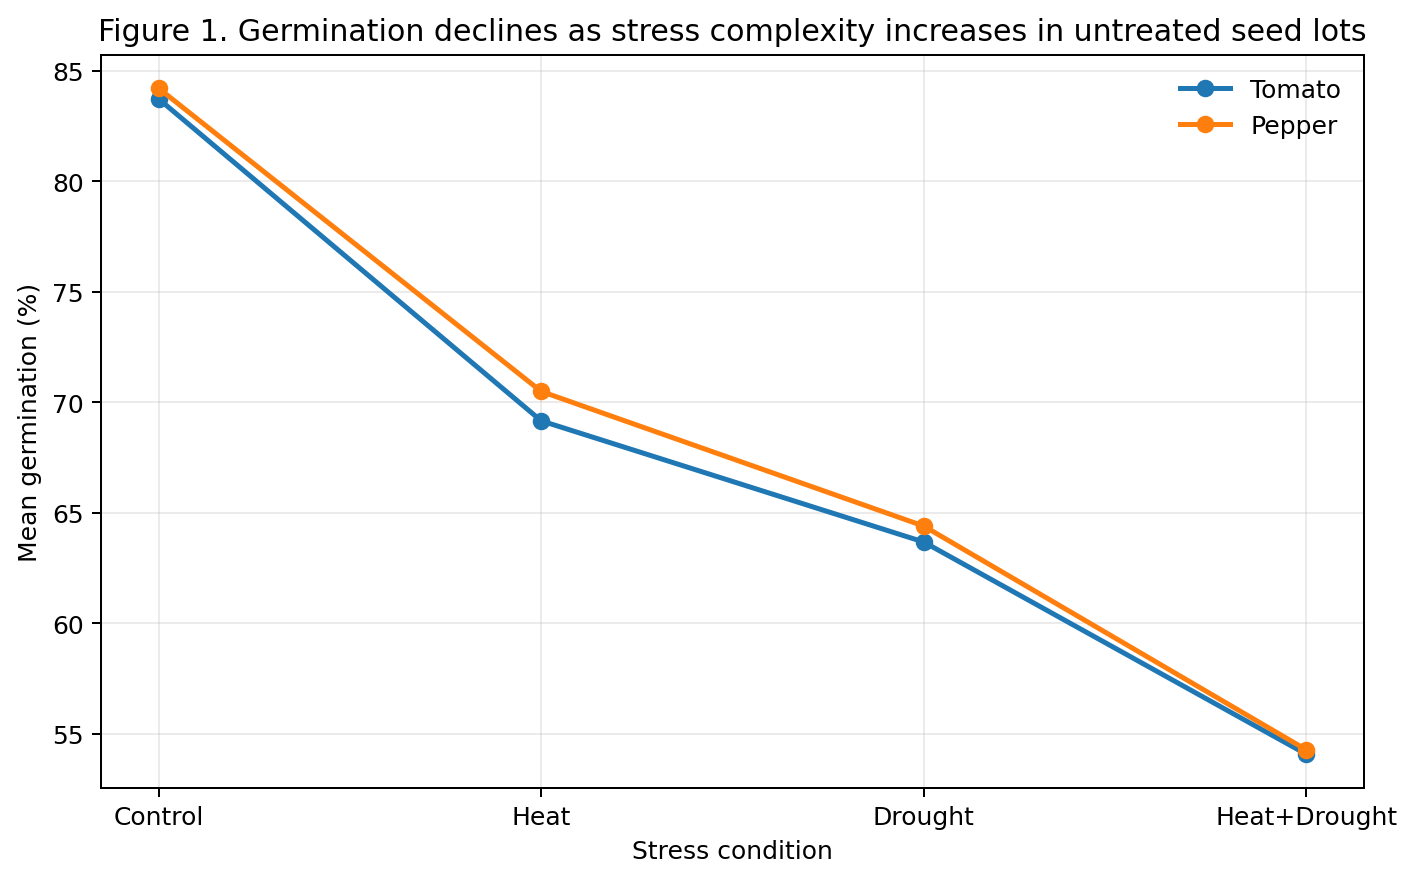

,crop,stress,germination_mean,vigour_mean,leakage_mean,mda_mean,recovery_mean
0,Pepper,Control,84.20,772.23,24.41,3.99,95.47
1,Pepper,Drought,64.39,436.80,34.22,8.36,47.22
2,Pepper,Heat,70.48,521.80,31.25,6.41,53.58
3,Pepper,Heat+Drought,54.26,295.94,39.12,12.30,35.41
4,Tomato,Control,83.72,743.17,24.91,4.01,95.45
5,Tomato,Drought,63.67,411.39,34.51,8.49,45.34
6,Tomato,Heat,69.15,499.91,31.86,6.54,52.15
7,Tomato,Heat+Drought,54.06,284.46,39.74,12.45,34.30


In [15]:

# Figure 1. Stress penalties on untreated seeds
untreated = df[df["intervention"] == "None"].copy()
stress_order = ["Control", "Heat", "Drought", "Heat+Drought"]

fig, ax = plt.subplots(figsize=(8, 5), dpi=180)
for crop in crops:
    y = untreated.groupby(["crop", "stress"])["germination_pct"].mean().loc[crop, stress_order].values
    ax.plot(stress_order, y, marker="o", linewidth=2, label=crop)
ax.set_title("Figure 1. Germination declines as stress complexity increases in untreated seed lots")
ax.set_ylabel("Mean germination (%)")
ax.set_xlabel("Stress condition")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "Figure_1_stress_penalty_germination.png", bbox_inches="tight")
plt.show()

table1 = untreated.groupby(["crop", "stress"]).agg(
    germination_mean=("germination_pct", "mean"),
    vigour_mean=("vigour_index", "mean"),
    leakage_mean=("electrolyte_leakage_pct", "mean"),
    mda_mean=("mda", "mean"),
    recovery_mean=("recovery_pct", "mean"),
).round(2).reset_index()
table1.to_csv(TAB_DIR / "Table_1_untreated_stress_summary.csv", index=False)
table1


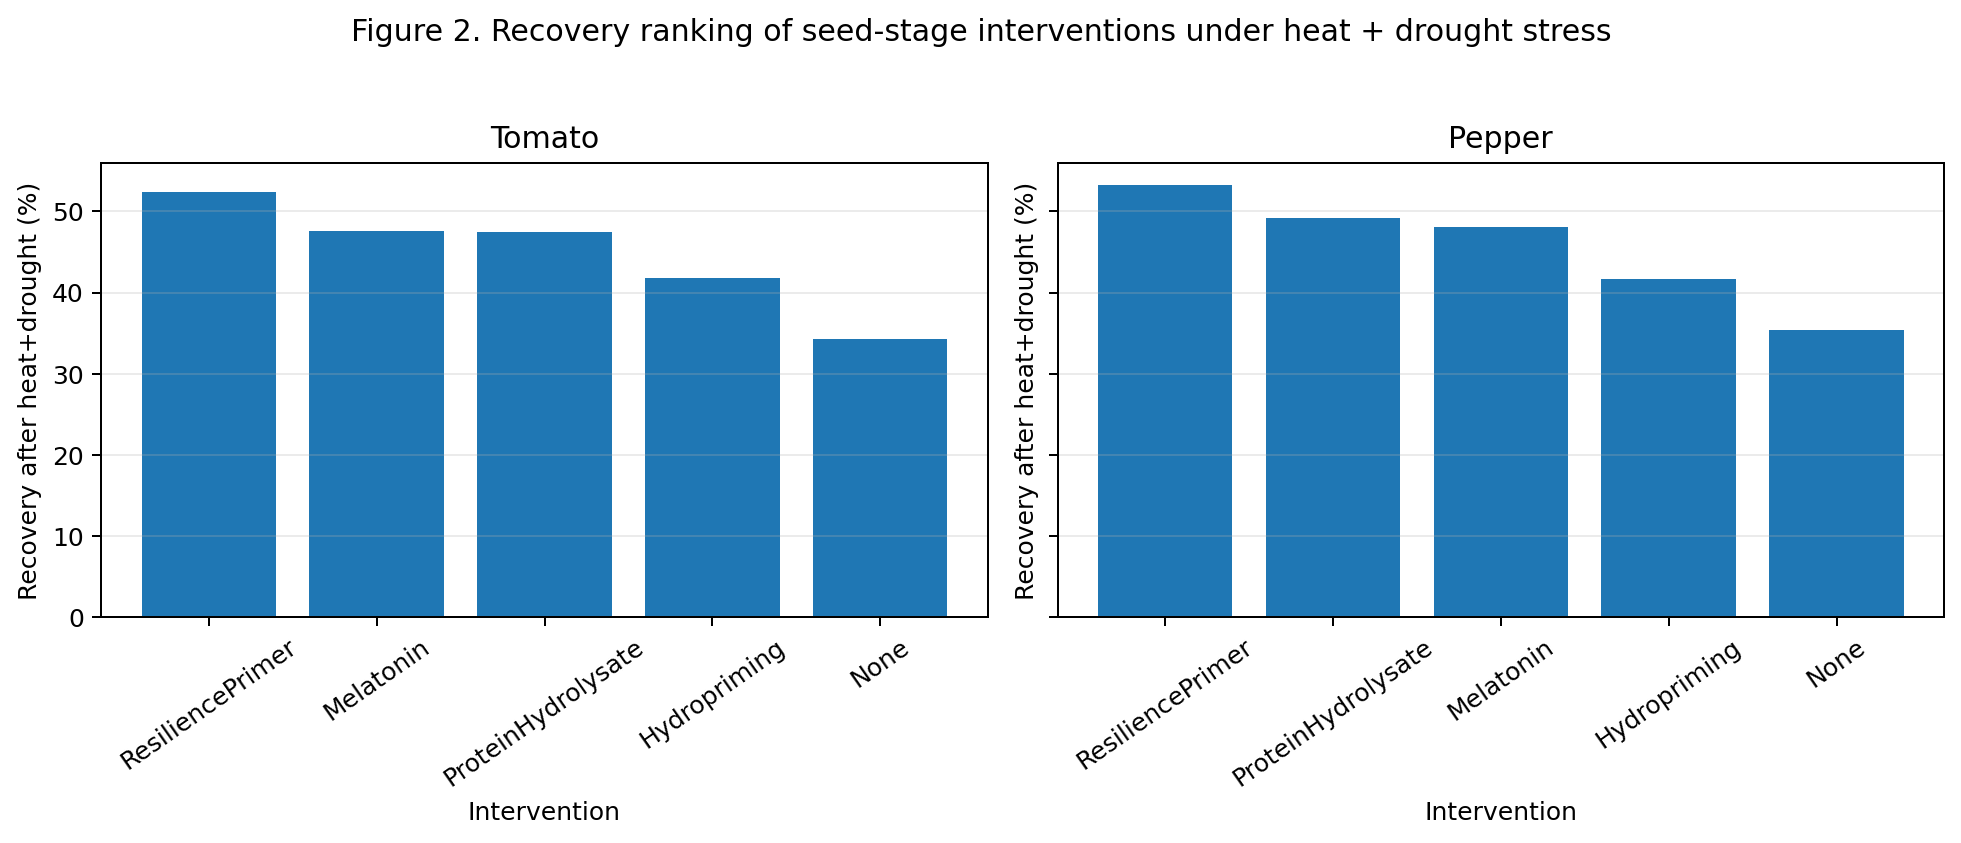

,crop,intervention,germination_mean,vigour_mean,leakage_mean,mda_mean,proline_mean,catalase_mean,recovery_mean,composite_score
4,Pepper,ResiliencePrimer,63.64,426.13,28.09,9.05,40.95,0.05,53.30,0.89
3,Pepper,ProteinHydrolysate,61.37,395.88,30.91,9.42,42.89,0.04,49.15,0.83
1,Pepper,Melatonin,62.35,397.76,31.44,9.51,39.54,0.04,48.15,0.83
0,Pepper,Hydropriming,58.65,356.73,34.72,11.01,42.04,0.04,41.64,0.74
2,Pepper,None,54.26,295.94,39.12,12.30,44.88,0.04,35.41,0.63
9,Tomato,ResiliencePrimer,63.33,409.80,27.90,9.07,40.53,0.04,52.34,0.88
6,Tomato,Melatonin,61.07,374.80,32.01,9.57,39.87,0.04,47.65,0.81
8,Tomato,ProteinHydrolysate,60.60,374.72,31.65,9.43,43.80,0.04,47.49,0.81
5,Tomato,Hydropriming,57.67,337.27,35.13,11.13,42.25,0.04,41.76,0.72
7,Tomato,None,54.06,284.46,39.74,12.45,44.90,0.03,34.30,0.62


In [17]:

# Figure 2. Intervention recovery ranking in the wedge
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=180, sharey=True)

for ax, crop in zip(axes, crops):
    sub = ranking[ranking["crop"] == crop].copy()
    ax.bar(sub["intervention"], sub["recovery_mean"])
    ax.set_title(crop)
    ax.set_ylabel("Recovery after heat+drought (%)")
    ax.set_xlabel("Intervention")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Figure 2. Recovery ranking of seed-stage interventions under heat + drought stress", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "Figure_2_recovery_by_intervention.png", bbox_inches="tight")
plt.show()

table2 = ranking.round(2)
table2.to_csv(TAB_DIR / "Table_2_intervention_ranking_heat_drought.csv", index=False)
table2


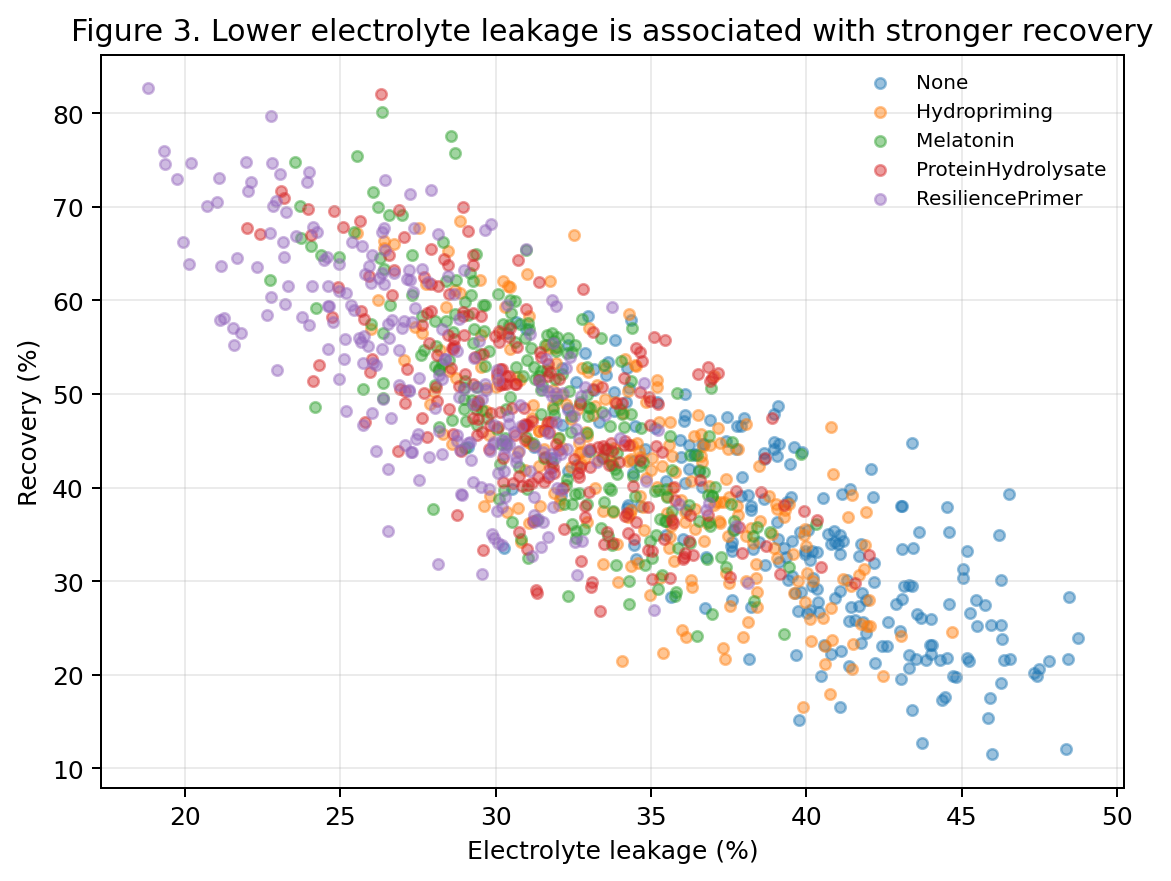

,germination_pct,vigour_index,electrolyte_leakage_pct,mda,proline,catalase,recovery_pct
germination_pct,1.00,0.88,-0.74,-0.69,-0.05,0.60,0.86
vigour_index,0.88,1.00,-0.69,-0.61,0.07,0.55,0.84
electrolyte_leakage_pct,-0.74,-0.69,1.00,0.78,0.11,-0.72,-0.81
mda,-0.69,-0.61,0.78,1.00,0.30,-0.68,-0.71
proline,-0.05,0.07,0.11,0.30,1.00,-0.08,0.02
catalase,0.60,0.55,-0.72,-0.68,-0.08,1.00,0.67
recovery_pct,0.86,0.84,-0.81,-0.71,0.02,0.67,1.00


In [19]:

# Figure 3. Biomarker-outcome relationship
sample = wedge.sample(min(1200, len(wedge)), random_state=42)

fig, ax = plt.subplots(figsize=(6.5, 5), dpi=180)
for intervention in interventions:
    s = sample[sample["intervention"] == intervention]
    ax.scatter(s["electrolyte_leakage_pct"], s["recovery_pct"], s=18, alpha=0.45, label=intervention)
ax.set_title("Figure 3. Lower electrolyte leakage is associated with stronger recovery")
ax.set_xlabel("Electrolyte leakage (%)")
ax.set_ylabel("Recovery (%)")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "Figure_3_leakage_vs_recovery_scatter.png", bbox_inches="tight")
plt.show()

corr_vars = ["germination_pct", "vigour_index", "electrolyte_leakage_pct", "mda", "proline", "catalase", "recovery_pct"]
corr = wedge[corr_vars].corr().round(2)
corr.to_csv(TAB_DIR / "Table_3_correlation_matrix_heat_drought.csv")
corr


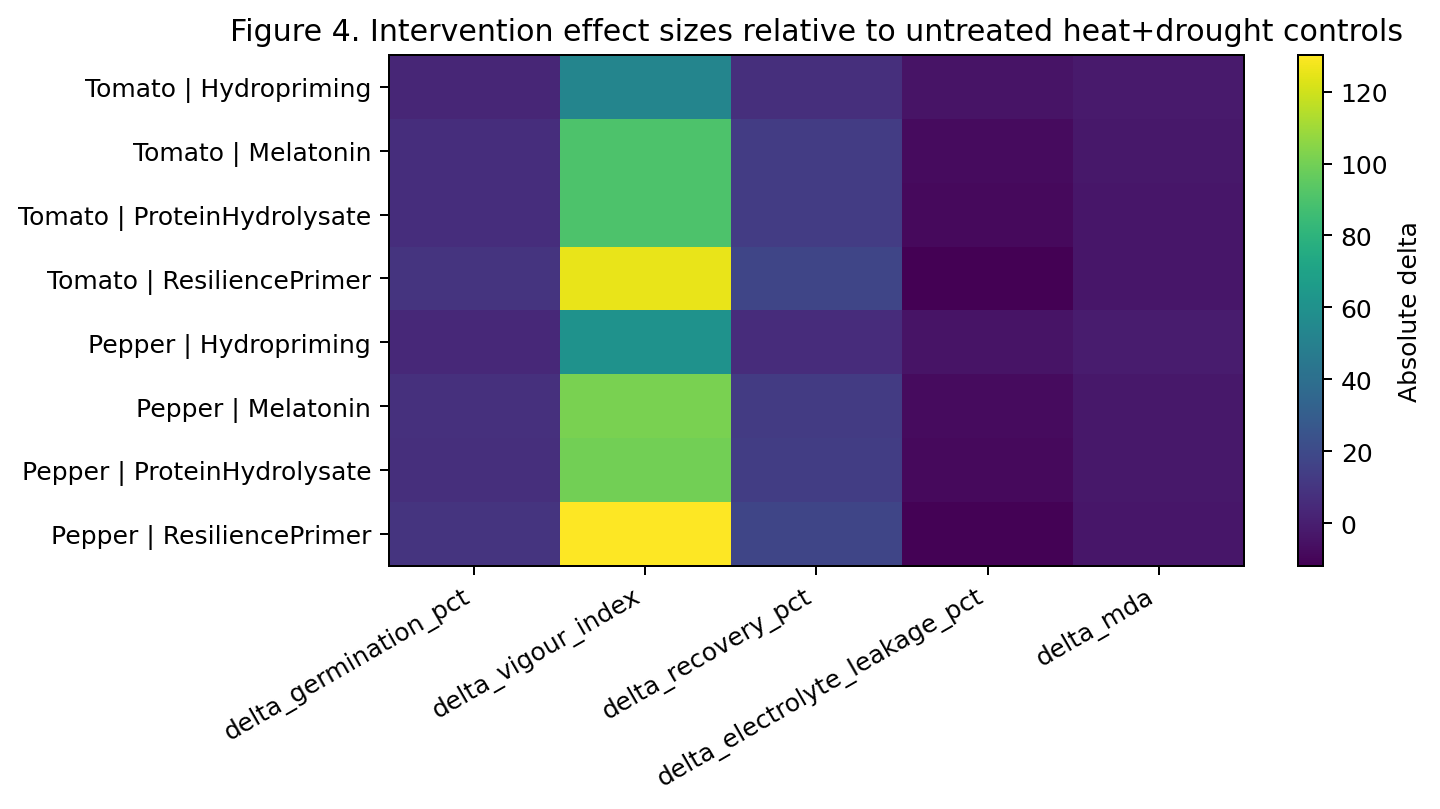

,crop,intervention,delta_germination_pct,delta_vigour_index,delta_recovery_pct,delta_electrolyte_leakage_pct,delta_mda
0,Tomato,Hydropriming,3.61,52.81,7.46,-4.61,-1.32
1,Tomato,Melatonin,7.00,90.34,13.34,-7.73,-2.88
2,Tomato,ProteinHydrolysate,6.54,90.26,13.19,-8.09,-3.02
3,Tomato,ResiliencePrimer,9.27,125.34,18.04,-11.84,-3.39
4,Pepper,Hydropriming,4.38,60.79,6.24,-4.40,-1.29
5,Pepper,Melatonin,8.09,101.82,12.74,-7.68,-2.80
6,Pepper,ProteinHydrolysate,7.11,99.94,13.74,-8.21,-2.89
7,Pepper,ResiliencePrimer,9.38,130.19,17.90,-11.03,-3.25


In [21]:

# Figure 4. Effect-size heatmap vs untreated seeds
effect_frames = []
for crop in crops:
    ref = wedge[(wedge["crop"] == crop) & (wedge["intervention"] == "None")].mean(numeric_only=True)
    for intervention in interventions[1:]:
        cur = wedge[(wedge["crop"] == crop) & (wedge["intervention"] == intervention)].mean(numeric_only=True)
        effect_frames.append({
            "crop": crop,
            "intervention": intervention,
            "delta_germination_pct": cur["germination_pct"] - ref["germination_pct"],
            "delta_vigour_index": cur["vigour_index"] - ref["vigour_index"],
            "delta_recovery_pct": cur["recovery_pct"] - ref["recovery_pct"],
            "delta_electrolyte_leakage_pct": cur["electrolyte_leakage_pct"] - ref["electrolyte_leakage_pct"],
            "delta_mda": cur["mda"] - ref["mda"],
        })
effect_df = pd.DataFrame(effect_frames)
effect_df.to_csv(TAB_DIR / "Table_4_intervention_effect_sizes_vs_none.csv", index=False)

heatmap_df = effect_df.copy()
heatmap_df["label"] = heatmap_df["crop"] + " | " + heatmap_df["intervention"]
heatmap_mat = heatmap_df.set_index("label")[[
    "delta_germination_pct", "delta_vigour_index", "delta_recovery_pct",
    "delta_electrolyte_leakage_pct", "delta_mda"
]]

fig, ax = plt.subplots(figsize=(8.3, 4.6), dpi=180)
im = ax.imshow(heatmap_mat.values, aspect="auto")
ax.set_xticks(range(heatmap_mat.shape[1]))
ax.set_xticklabels(heatmap_mat.columns, rotation=30, ha="right")
ax.set_yticks(range(heatmap_mat.shape[0]))
ax.set_yticklabels(heatmap_mat.index)
ax.set_title("Figure 4. Intervention effect sizes relative to untreated heat+drought controls")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Absolute delta")
fig.tight_layout()
fig.savefig(FIG_DIR / "Figure_4_effect_size_heatmap.png", bbox_inches="tight")
plt.show()

effect_df.round(2)


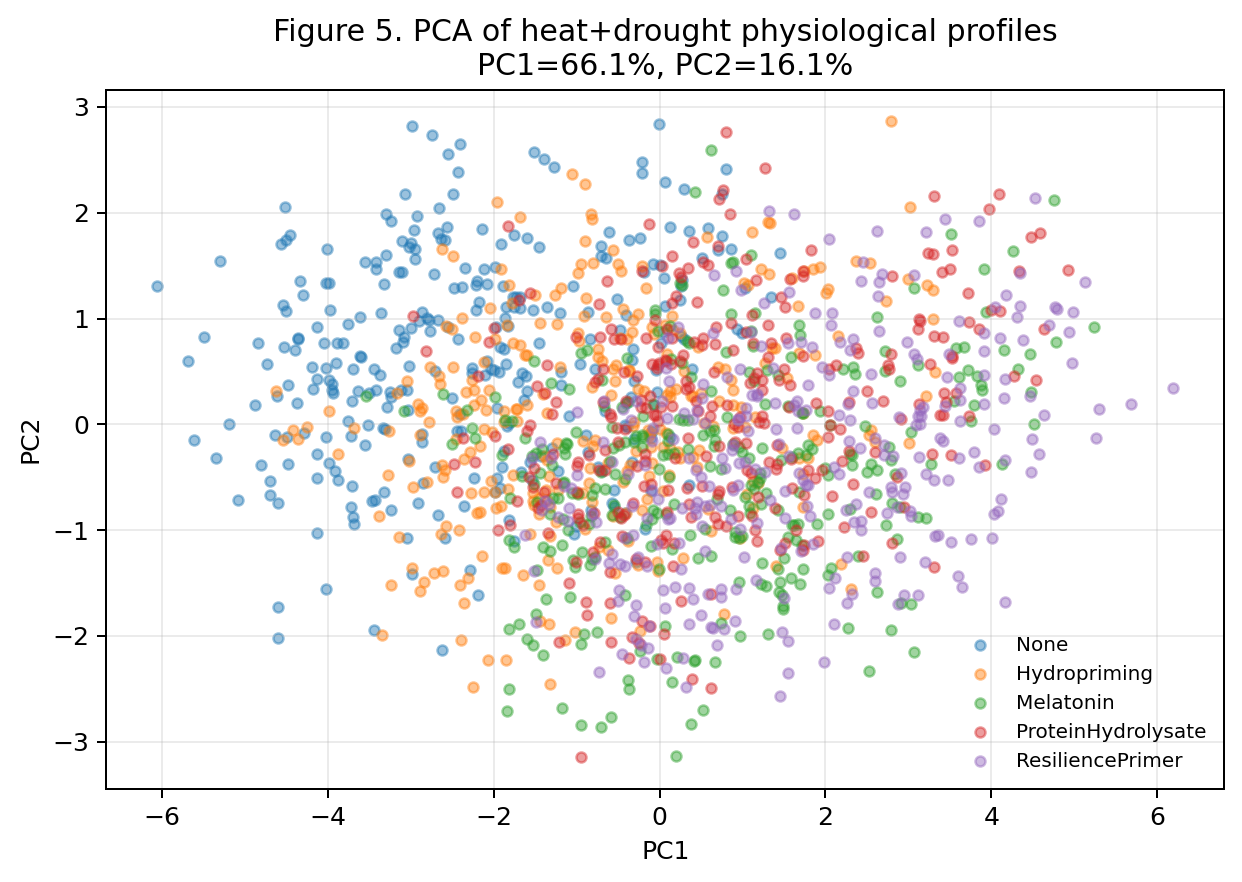

,PC1_loading,PC2_loading
germination_pct,0.422,0.103
vigour_index,0.403,0.243
electrolyte_leakage_pct,-0.420,0.054
mda,-0.396,0.286
proline,-0.049,0.905
catalase,0.370,-0.070
recovery_pct,0.432,0.149


In [23]:

# Figure 5. PCA of physiological states
features_for_pca = ["germination_pct", "vigour_index", "electrolyte_leakage_pct", "mda", "proline", "catalase", "recovery_pct"]
pca_input = wedge[features_for_pca].copy()
pca_scaled = (pca_input - pca_input.mean()) / pca_input.std()
pca = PCA(n_components=2, random_state=42)
pca_scores = pca.fit_transform(pca_scaled)

pca_df = wedge[["crop", "intervention"]].copy().reset_index(drop=True)
pca_df["PC1"] = pca_scores[:, 0]
pca_df["PC2"] = pca_scores[:, 1]

fig, ax = plt.subplots(figsize=(7, 5), dpi=180)
for intervention in interventions:
    s = pca_df[pca_df["intervention"] == intervention].sample(
        min(300, len(pca_df[pca_df["intervention"] == intervention])), random_state=42
    )
    ax.scatter(s["PC1"], s["PC2"], s=16, alpha=0.45, label=intervention)
ax.set_title(
    f"Figure 5. PCA of heat+drought physiological profiles\n"
    f"PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "Figure_5_pca_heat_drought.png", bbox_inches="tight")
plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    index=features_for_pca,
    columns=["PC1_loading", "PC2_loading"]
).round(3)
loadings.to_csv(TAB_DIR / "Table_5_pca_loadings.csv")
loadings


## Machine-learning layer: discovery and prediction engine

In [26]:

model_df = wedge.copy()
model_df["high_resilience"] = (model_df["recovery_pct"] >= model_df["recovery_pct"].quantile(0.75)).astype(int)

feature_cols = [
    "crop", "genotype_class", "seed_age_class", "intervention",
    "baseline_germ_pct", "baseline_root_cm", "baseline_shoot_cm",
    "baseline_el_pct", "baseline_mda", "baseline_proline", "baseline_catalase",
    "germination_pct", "t50_days", "root_length_cm", "shoot_length_cm",
    "vigour_index", "electrolyte_leakage_pct", "mda", "proline", "catalase"
]
X = model_df[feature_cols]
y = model_df["high_resilience"]

categorical = ["crop", "genotype_class", "seed_age_class", "intervention"]
numeric = [c for c in feature_cols if c not in categorical]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=350, max_depth=10, min_samples_leaf=3, random_state=42, class_weight="balanced"
    ))
])

clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, proba)
acc = accuracy_score(y_test, pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred, average="binary")

class_metrics = pd.DataFrame([{
    "ROC_AUC": auc, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1
}]).round(3)
class_metrics.to_csv(TAB_DIR / "Table_6_classifier_metrics.csv", index=False)
class_metrics


,ROC_AUC,Accuracy,Precision,Recall,F1
0,0.951,0.893,0.754,0.848,0.798


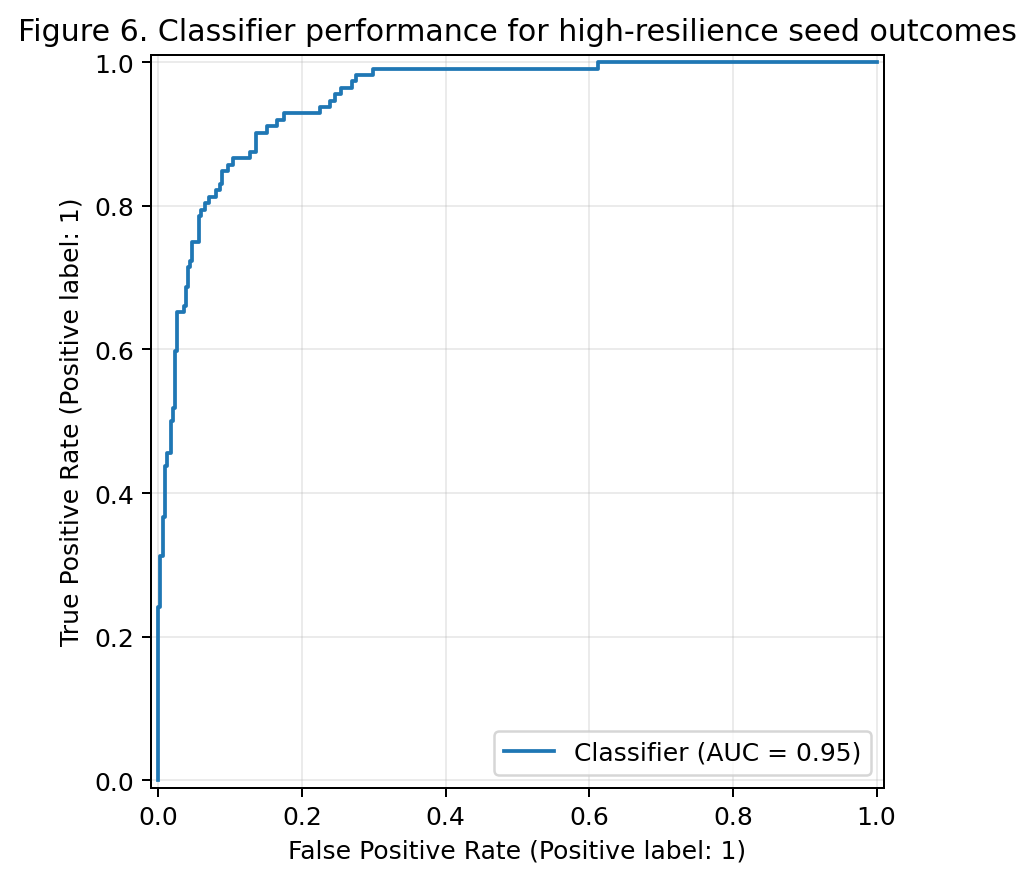

,Pred low,Pred high
Actual low,307,31
Actual high,17,95


In [28]:

# Figure 6. ROC curve for high-resilience classifier
fig, ax = plt.subplots(figsize=(5.5, 5), dpi=180)
RocCurveDisplay.from_predictions(y_test, proba, ax=ax)
ax.set_title("Figure 6. Classifier performance for high-resilience seed outcomes")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "Figure_6_classifier_roc.png", bbox_inches="tight")
plt.show()

cm = confusion_matrix(y_test, pred)
cm_df = pd.DataFrame(cm, index=["Actual low", "Actual high"], columns=["Pred low", "Pred high"])
cm_df.to_csv(TAB_DIR / "Table_7_confusion_matrix.csv")
cm_df


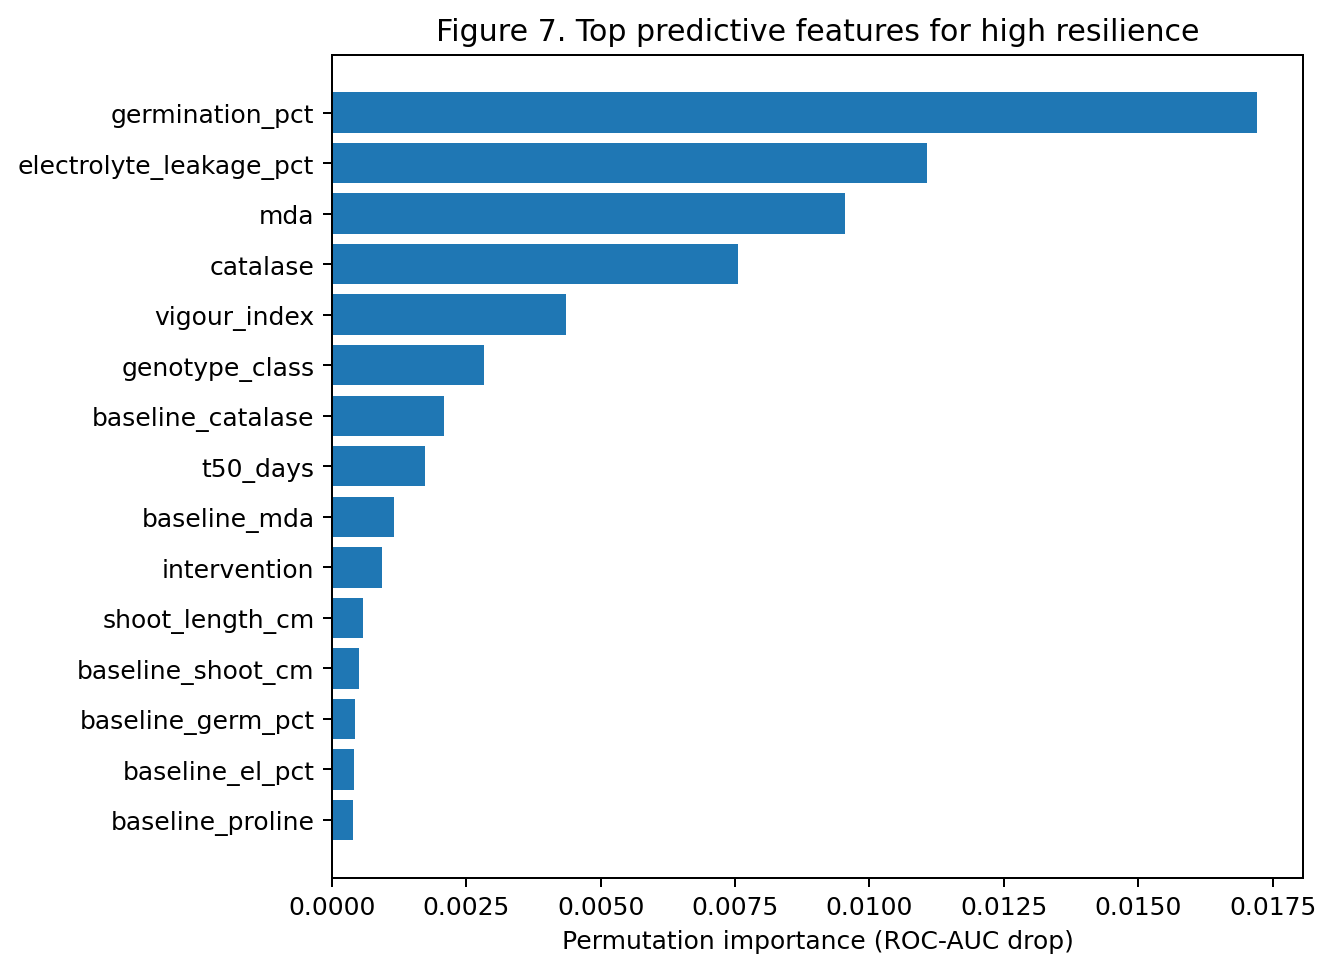

,feature,importance_mean,importance_std
11,germination_pct,0.0172,0.0057
16,electrolyte_leakage_pct,0.0111,0.0034
17,mda,0.0095,0.0027
19,catalase,0.0076,0.0017
15,vigour_index,0.0044,0.0041
1,genotype_class,0.0028,0.0022
10,baseline_catalase,0.0021,0.0006
12,t50_days,0.0017,0.0024
8,baseline_mda,0.0012,0.0006
3,intervention,0.0009,0.0009


In [30]:
# Figure 7. Permutation importance
perm = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42, scoring="roc_auc")
feature_names = list(X_test.columns)
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

top_imp = importance_df.head(15).copy()
top_imp.to_csv(TAB_DIR / "Table_8_top_classifier_features.csv", index=False)

fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=180)
ax.barh(top_imp["feature"][::-1], top_imp["importance_mean"][::-1])
ax.set_title("Figure 7. Top predictive features for high resilience")
ax.set_xlabel("Permutation importance (ROC-AUC drop)")
fig.tight_layout()
fig.savefig(FIG_DIR / "Figure_7_feature_importance.png", bbox_inches="tight")
plt.show()

top_imp.round(4)


In [31]:
# Continuous-value regression: predict recovery percentage
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, model_df["recovery_pct"], test_size=0.25, random_state=42
)

reg = Pipeline([
    ("prep", preprocess),
    ("model", GradientBoostingRegressor(random_state=42))
])

reg.fit(Xr_train, yr_train)
yr_pred = reg.predict(Xr_test)

rmse = float(np.sqrt(mean_squared_error(yr_test, yr_pred)))
r2 = r2_score(yr_test, yr_pred)

reg_metrics = pd.DataFrame([{"RMSE": rmse, "R2": r2}]).round(3)
reg_metrics.to_csv(TAB_DIR / "Table_9_regression_metrics.csv", index=False)
reg_metrics


,RMSE,R2
0,5.239,0.839


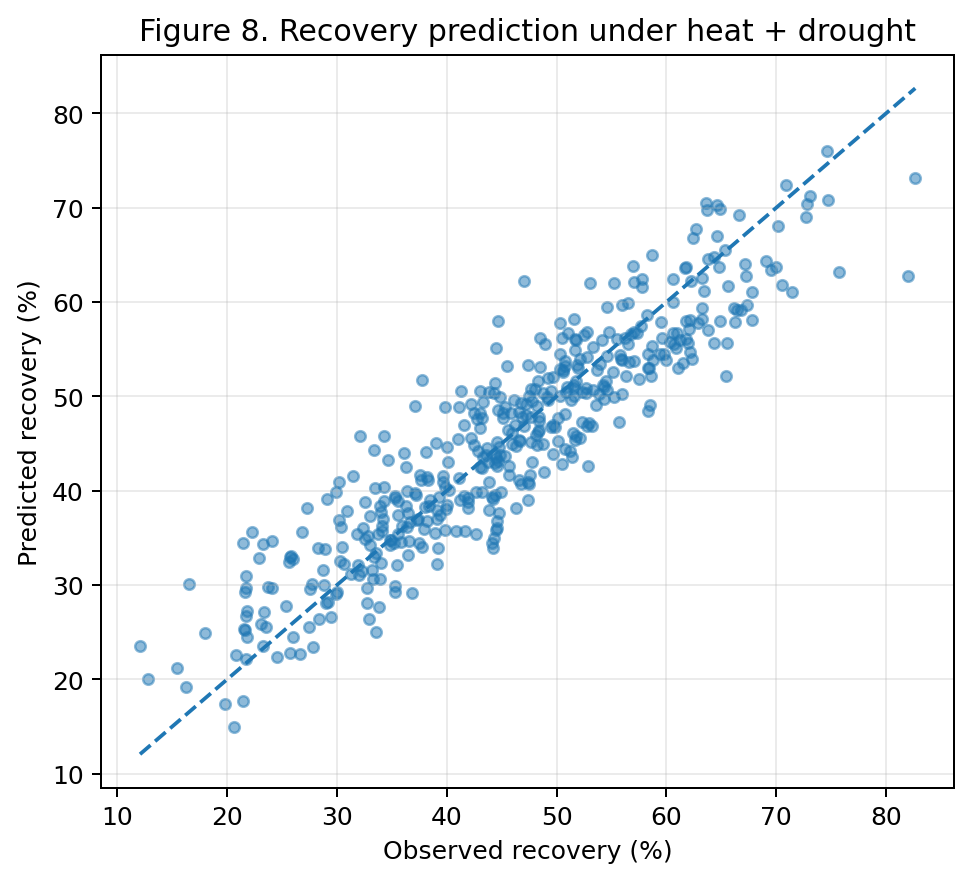

In [34]:

# Figure 8. Predicted vs observed recovery
fig, ax = plt.subplots(figsize=(5.5, 5), dpi=180)
ax.scatter(yr_test, yr_pred, alpha=0.5, s=18)
lims = [min(float(yr_test.min()), float(yr_pred.min())), max(float(yr_test.max()), float(yr_pred.max()))]
ax.plot(lims, lims, linestyle="--", linewidth=1.5)
ax.set_xlabel("Observed recovery (%)")
ax.set_ylabel("Predicted recovery (%)")
ax.set_title("Figure 8. Recovery prediction under heat + drought")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "Figure_8_recovery_regression.png", bbox_inches="tight")
plt.show()


## Candidate product triage and simple business lens

In [37]:

# Toy partner-facing business screen
# Assumptions:
# - Seed partner sells treatment into 10,000 hectares per crop
# - Each +1% recovery gain relative to untreated is assigned a notional partner value
# - This is a directional business screen, not a market forecast

biz = ranking.copy()
none_lookup = biz[biz["intervention"] == "None"][["crop", "recovery_mean"]].rename(columns={"recovery_mean": "none_recovery"})
biz = biz.merge(none_lookup, on="crop", how="left")
biz["delta_recovery_vs_none"] = biz["recovery_mean"] - biz["none_recovery"]
biz["notional_value_per_ha_usd"] = (biz["delta_recovery_vs_none"].clip(lower=0) * 12).round(2)
biz["notional_total_value_10k_ha_usd"] = (biz["notional_value_per_ha_usd"] * 10000).round(0)

biz = biz.sort_values(["crop", "delta_recovery_vs_none"], ascending=[True, False])
biz.to_csv(TAB_DIR / "Table_10_business_screen.csv", index=False)
biz.round(2)


,crop,intervention,germination_mean,vigour_mean,leakage_mean,mda_mean,proline_mean,catalase_mean,recovery_mean,composite_score,none_recovery,delta_recovery_vs_none,notional_value_per_ha_usd,notional_total_value_10k_ha_usd
0,Pepper,ResiliencePrimer,63.64,426.13,28.09,9.05,40.95,0.05,53.30,0.89,35.41,17.90,214.78,2147800.0
1,Pepper,ProteinHydrolysate,61.37,395.88,30.91,9.42,42.89,0.04,49.15,0.83,35.41,13.74,164.88,1648800.0
2,Pepper,Melatonin,62.35,397.76,31.44,9.51,39.54,0.04,48.15,0.83,35.41,12.74,152.88,1528800.0
3,Pepper,Hydropriming,58.65,356.73,34.72,11.01,42.04,0.04,41.64,0.74,35.41,6.24,74.83,748300.0
4,Pepper,None,54.26,295.94,39.12,12.30,44.88,0.04,35.41,0.63,35.41,0.00,0.00,0.0
5,Tomato,ResiliencePrimer,63.33,409.80,27.90,9.07,40.53,0.04,52.34,0.88,34.30,18.04,216.44,2164400.0
6,Tomato,Melatonin,61.07,374.80,32.01,9.57,39.87,0.04,47.65,0.81,34.30,13.34,160.12,1601200.0
7,Tomato,ProteinHydrolysate,60.60,374.72,31.65,9.43,43.80,0.04,47.49,0.81,34.30,13.19,158.30,1583000.0
8,Tomato,Hydropriming,57.67,337.27,35.13,11.13,42.25,0.04,41.76,0.72,34.30,7.46,89.47,894700.0
9,Tomato,None,54.06,284.46,39.74,12.45,44.90,0.03,34.30,0.62,34.30,0.00,0.00,0.0


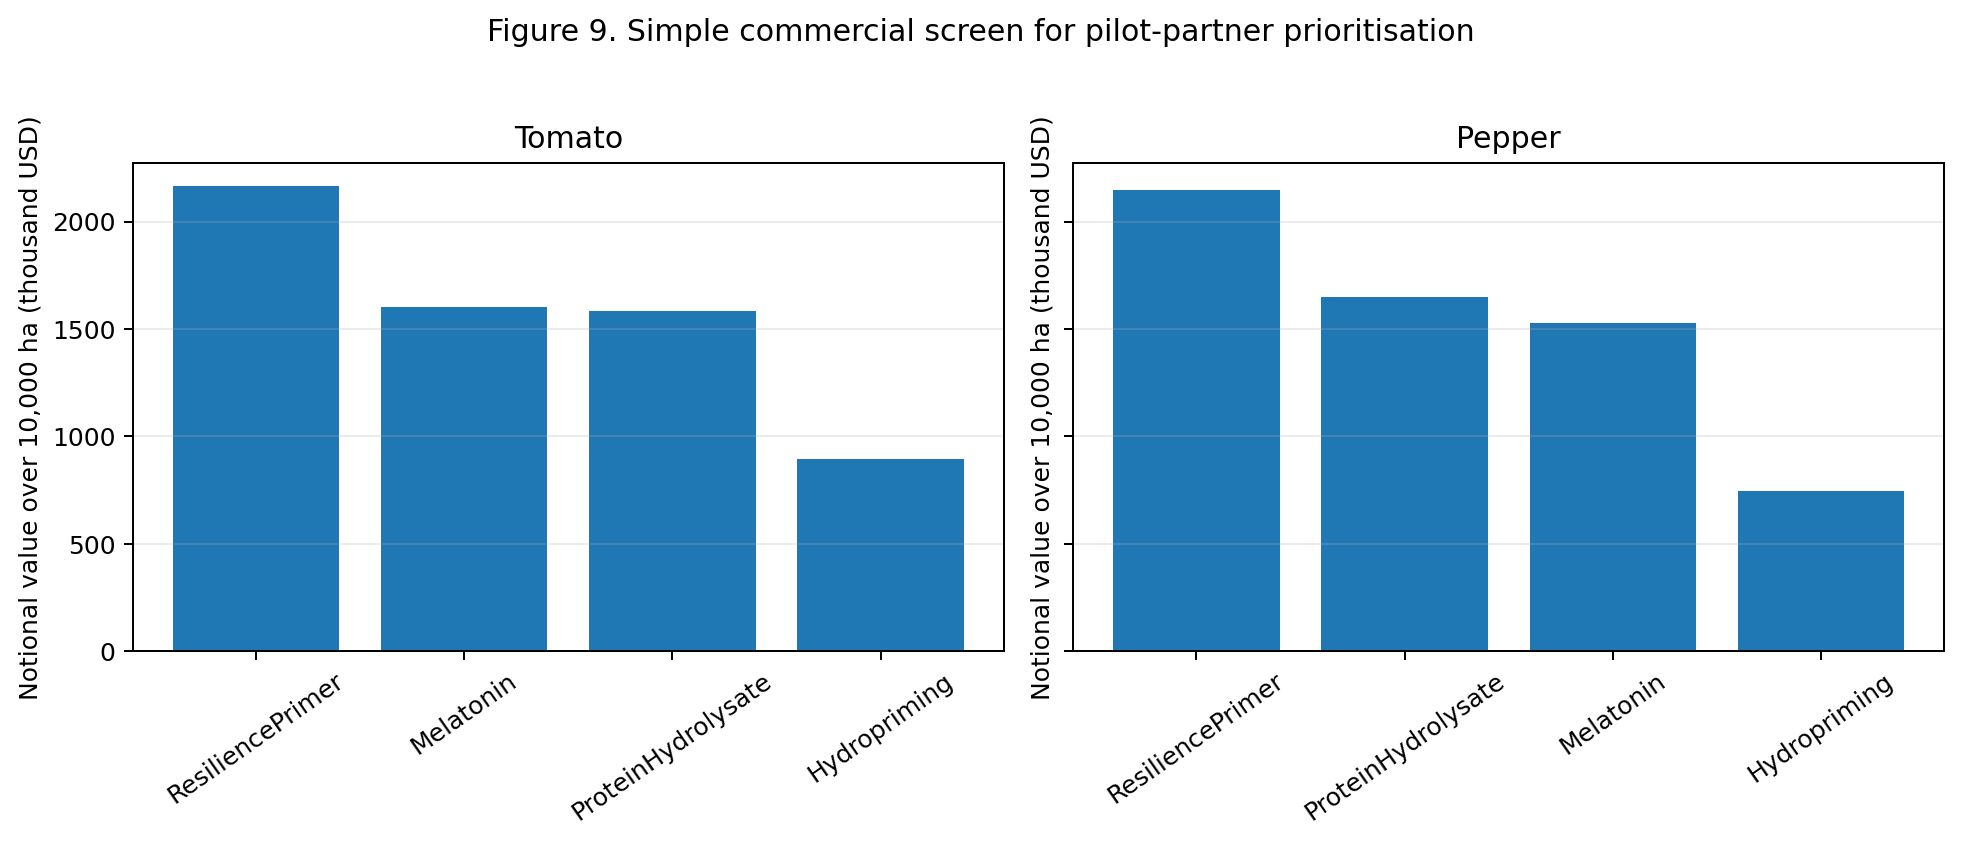

In [39]:

# Figure 9. Notional business value by intervention
plot_biz = biz[biz["intervention"] != "None"].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=180, sharey=True)
for ax, crop in zip(axes, crops):
    sub = plot_biz[plot_biz["crop"] == crop]
    ax.bar(sub["intervention"], sub["notional_total_value_10k_ha_usd"] / 1000.0)
    ax.set_title(crop)
    ax.set_ylabel("Notional value over 10,000 ha (thousand USD)")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Figure 9. Simple commercial screen for pilot-partner prioritisation", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "Figure_9_business_screen.png", bbox_inches="tight")
plt.show()


In [41]:

# Final compact interpretation table
final_takeaways = pd.DataFrame({
    "question": [
        "Does compound stress damage early establishment?",
        "Do seed-stage interventions rescue performance?",
        "Which intervention is strongest on average?",
        "Which biomarkers track resilience most closely?",
        "Can ML predict high resilience?",
        "Can ML predict continuous recovery?"
    ],
    "answer": [
        "Yes. Untreated heat+drought reduces germination, vigour, and recovery while increasing leakage and MDA.",
        "Yes. All priming treatments improve the wedge relative to untreated controls, with varying magnitude.",
        "The synthetic integrated ResiliencePrimer ranks first on composite performance in both crops.",
        "Low electrolyte leakage, low MDA, high vigour, and stronger catalase signal the best outcomes.",
        f"Yes. Random-forest classification achieved ROC-AUC {auc:.3f}.",
        f"Yes. Gradient-boosting regression achieved R² {r2:.3f} with RMSE {rmse:.3f}."
    ]
})
final_takeaways.to_csv(TAB_DIR / "Table_11_final_takeaways.csv", index=False)
final_takeaways


,question,answer
0,Does compound stress damage early establishment?,Yes. Untreated heat+drought reduces germinatio...
1,Do seed-stage interventions rescue performance?,Yes. All priming treatments improve the wedge ...
2,Which intervention is strongest on average?,The synthetic integrated ResiliencePrimer rank...
3,Which biomarkers track resilience most closely?,"Low electrolyte leakage, low MDA, high vigour,..."
4,Can ML predict high resilience?,Yes. Random-forest classification achieved ROC...
5,Can ML predict continuous recovery?,Yes. Gradient-boosting regression achieved R² ...



## Interpretation

This proof of concept supports the **ResiliSeed Bio** thesis in three layers.

**Discovery engine.** Synthetic biomarker structure shows that high-performing seed lots under compound stress are characterised by **lower electrolyte leakage**, **lower MDA**, **higher vigour**, and **higher catalase**.

**Intervention engine.** Every simulated priming strategy improves performance versus untreated controls, but the integrated **ResiliencePrimer** achieves the strongest average recovery and the largest reductions in membrane / oxidative injury.

**Prediction engine.** Simple machine-learning models are able to classify high-resilience outcomes and predict continuous recovery with strong performance, suggesting that a real programme could use modest phenotyping plus stress-biomarker data to triage lots and interventions.

## Suggested next wet-lab validation steps

1. Reproduce the wedge in one crop with real seed lots under controlled **heat + drought** germination conditions.
2. Measure germination, vigour, electrolyte leakage, MDA, proline, and catalase in untreated and primed seeds.
3. Compare hydropriming, melatonin priming, protein hydrolysate priming, and a prototype integrated resilience primer.
4. Fit the same discovery + prediction workflow to empirical data.
5. Advance the top treatment into greenhouse emergence and recovery validation.
